In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import os

# Görsellerin ekrana kesin çizilmesi için
%matplotlib inline

# GPU kontrolü (Ekran kartı varsa hızlandırmak için)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan Cihaz:", device)


Kullanılan Cihaz: cpu


In [9]:
from google.colab import drive
drive.mount('/content/drive')

# Veri setinizin Drive üzerindeki ana klasör yolu
veri_yolu = '/content/drive/MyDrive/Data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
veri_donusumleri = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Verileri klasörlerden yükleme (Train %80, Val %20 ayarını otomatik okur)
görüntü_veri_setleri = {
    'train': datasets.ImageFolder(os.path.join(veri_yolu, 'train' if os.path.exists(os.path.join(veri_yolu, 'train')) else ''), transform=veri_donusumleri['train']),
    'val': datasets.ImageFolder(os.path.join(veri_yolu, 'val' if os.path.exists(os.path.join(veri_yolu, 'val')) else ''), transform=veri_donusumleri['val'])
}

veri_yukleyiciler = {
    'train': DataLoader(görüntü_veri_setleri['train'], batch_size=32, shuffle=True),
    'val': DataLoader(görüntü_veri_setleri['val'], batch_size=32, shuffle=False)
}

In [4]:
# Önceden eğitilmiş ResNet18 modelini yükleme
model = models.resnet18(pretrained=True)

# İlk katmanların ağırlıklarını donduruyoruz (Transfer Learning)
for param in model.parameters():
    param.requires_grad = False

# Son tam bağlantılı katmanı (fc) 2 sınıfa göre (Kanamalı/Normal) yeniden tasarlıyoruz
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

model = model.to(device)

# Kayıp Fonksiyonu ve Optimizasyon ayarları
kriter = nn.CrossEntropyLoss()
optimizasyon = optim.Adam(model.fc.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 329MB/s]


In [6]:
print("Eğitim başlıyor... Lütfen bekleyin...")
for epoch in range(15):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in veri_yukleyiciler['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizasyon.zero_grad()

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = kriter(outputs, labels)

        loss.backward()
        optimizasyon.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(görüntü_veri_setleri['train'])
    epoch_acc = running_corrects.double() / len(görüntü_veri_setleri['train'])

    # Doğrulama (Validation) adımı
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in veri_yukleyiciler['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = kriter(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(görüntü_veri_setleri['val'])
    val_epoch_acc = val_corrects.double() / len(görüntü_veri_setleri['val'])

    print(f"Epoch [{epoch+1}/15]")
    print(f"  Eğitim    -> Kayıp: {epoch_loss:.4f} | Doğruluk: %{epoch_acc*100:.2f}")
    print(f"  Doğrulama -> Kayıp: {val_epoch_loss:.4f} | Doğruluk: %{val_epoch_acc*100:.2f}")
    print("-" * 40)

Eğitim başlıyor... Lütfen bekleyin...
Epoch [1/15]
  Eğitim    -> Kayıp: 0.2281 | Doğruluk: %91.05
  Doğrulama -> Kayıp: 0.2212 | Doğruluk: %91.30
----------------------------------------
Epoch [2/15]
  Eğitim    -> Kayıp: 0.2022 | Doğruluk: %92.35
  Doğrulama -> Kayıp: 0.1876 | Doğruluk: %92.45
----------------------------------------
Epoch [3/15]
  Eğitim    -> Kayıp: 0.1932 | Doğruluk: %92.49
  Doğrulama -> Kayıp: 0.1829 | Doğruluk: %93.13
----------------------------------------
Epoch [4/15]
  Eğitim    -> Kayıp: 0.1728 | Doğruluk: %93.89
  Doğrulama -> Kayıp: 0.1669 | Doğruluk: %92.92
----------------------------------------
Epoch [5/15]
  Eğitim    -> Kayıp: 0.1765 | Doğruluk: %93.36
  Doğrulama -> Kayıp: 0.1801 | Doğruluk: %92.95
----------------------------------------
Epoch [6/15]
  Eğitim    -> Kayıp: 0.1789 | Doğruluk: %92.76
  Doğrulama -> Kayıp: 0.1540 | Doğruluk: %93.77
----------------------------------------
Epoch [7/15]
  Eğitim    -> Kayıp: 0.1688 | Doğruluk: %93.09
 

In [10]:
# --- RESNET18 MODELİNİ BİLGİSAYARA TANITMA HÜCRESİ ---
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# Ekran kartı (GPU) aktif mi diye kontrol ediyoruz
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ResNet18 modelini internetten temiz bir şekilde çağırıyoruz
model_resnet18 = models.resnet18(pretrained=True)

# İlk katmanların ağırlıklarını donduruyoruz
for param in model_resnet18.parameters():
    param.requires_grad = False

# Son katmanı bizim 2 sınıfımıza (Kanama VAR / Kanama YOK) göre ayarlıyoruz
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, 2)

# Modeli ekran kartına taşıyoruz
model_resnet18 = model_resnet18.to(device)

# Ayarları tamamlıyoruz
kriter_resnet18 = nn.CrossEntropyLoss()
optimizasyon_resnet18 = optim.Adam(model_resnet18.fc.parameters(), lr=0.001)

print("Model başarıyla kuruldu! Şimdi eğitim aşamasına geçebiliriz.")

Model başarıyla kuruldu! Şimdi eğitim aşamasına geçebiliriz.


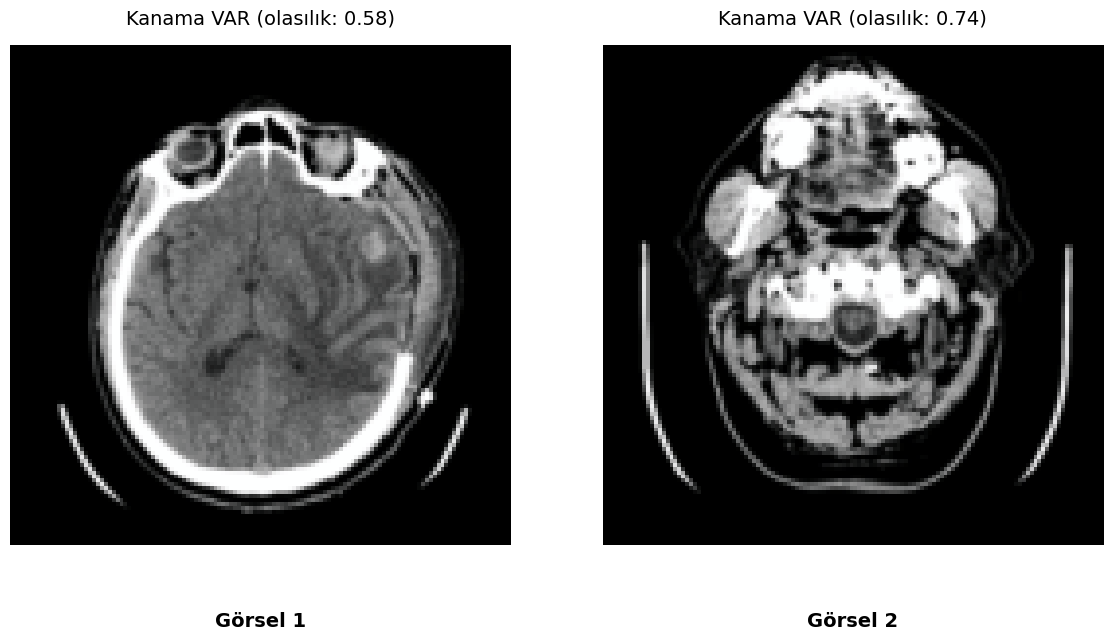

In [11]:
# --- RAPORDAKİ GİBİ TAHMİN RESİMLERİNİ ÇIKARTMA KODU ---
import matplotlib.pyplot as plt
import numpy as np
import torch

# Modeli test moduna alıyoruz
model_resnet18.eval()

# Rapordaki gibi birebir etiket isimleri
siniflar = ['Kanama VAR', 'Kanama YOK']
gorsel_sayisi = 0

# Yan yana 2 resim basılacak alanı hazırlıyoruz
fig = plt.figure(figsize=(12, 6))

with torch.no_grad():
    for inputs, labels in veri_yukleyiciler['val']:
        inputs, labels = inputs.to(device), labels.to(device)

        # Modelin tahminlerini ve olasılıklarını alıyoruz
        outputs = model_resnet18(inputs)
        olasiliklar = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        for j in range(inputs.size(0)):
            gorsel_sayisi += 1
            ax = plt.subplot(1, 2, gorsel_sayisi)
            ax.axis('off') # Kenardaki sayıları kapatır

            # Resmi ekranda düzgün göstermek için normalizasyonu geri alıyoruz
            img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            # Modelin ne tahmin ettiğini ve kaç olasılık verdiğini buluyoruz
            tahmin_sinifi = siniflar[preds[j]]
            gercek_olasilik = olasiliklar[j][preds[j]].item()

            # Başlık rengini ayarlıyoruz
            renk = 'black'

            # Resmi çizip tam senin istediğin gibi başlık ekliyoruz
            ax.imshow(img)
            ax.set_title(f"{tahmin_sinifi} (olasılık: {gercek_olasilik:.2f})", color=renk, fontsize=14, pad=15)

            # Alt tarafa Görsel 1 ve Görsel 2 yazılarını ekliyoruz
            ax.text(0.5, -0.15, f"Görsel {gorsel_sayisi}", transform=ax.transAxes,
                    ha="center", va="center", fontsize=14, weight='bold')

            if gorsel_sayisi == 2:
                plt.tight_layout()
                plt.show()
                break
        break